In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats


In [2]:
# Configuration
DATA_PATH = r"A:\Projects\DATA 202\Movies_and_TV_5.json.gz"
MIN_ITEM_RATINGS = 20
BENCHMARK_RATING = 4.0
CONFIDENCE_LEVEL = 0.95
SAVE_FIGURES = True
OUTPUT_DIR = r"A:\Projects\DATA 202\eda_figures"
USER_COUNT_UPPER_PERCENTILE = 99
ITEM_COUNT_UPPER_PERCENTILE = 99
SCATTER_MIN_ITEM_RATINGS = 20
SCATTER_SAMPLE_SIZE = 5000
EXPECTED_COLUMNS = ["item_id", "user_id", "rating", "timestamp"]


In [3]:
# Load and standardize the Amazon ratings data
df = pd.read_json(DATA_PATH, lines=True, compression="infer")
df = df.rename(columns={"asin": "item_id", "reviewerID": "user_id", "overall": "rating", "unixReviewTime": "timestamp"})
df = df[EXPECTED_COLUMNS].copy()
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")
df["year"] = df["datetime"].dt.year
df["month_period"] = df["datetime"].dt.to_period("M").astype("string")
rating_df = df.dropna(subset=["rating"]).copy()
print(df.head())
print()
print(df.shape)


      item_id         user_id  rating   timestamp   datetime  year  \
0  0005089549  A2M1CU2IRZG0K9       5  1352419200 2012-11-09  2012   
1  0005089549   AFTUJYISOFHY6       5  1325203200 2011-12-30  2011   
2  000503860X  A3JVF9Y53BEOGC       5  1114041600 2005-04-21  2005   
3  000503860X  A12VPEOEZS1KTC       5  1112745600 2005-04-06  2005   
4  000503860X   ATLZNVLYKP9AZ       5  1291334400 2010-12-03  2010   

  month_period  
0      2012-11  
1      2011-12  
2      2005-04  
3      2005-04  
4      2010-12  

(3410019, 7)


In [4]:
# Core dataset counts and rating summary statistics
row_count = len(df)
unique_users = df["user_id"].nunique(dropna=True)
unique_items = df["item_id"].nunique(dropna=True)
mean_rating = rating_df["rating"].mean()
median_rating = rating_df["rating"].median()
mode_series = rating_df["rating"].mode(dropna=True)
mode_rating = mode_series.iloc[0] if not mode_series.empty else np.nan
std_rating = rating_df["rating"].std()
min_rating = rating_df["rating"].min()
max_rating = rating_df["rating"].max()
quartiles = rating_df["rating"].quantile([0.25, 0.50, 0.75])
rating_counts = rating_df["rating"].value_counts().sort_index()
print("CORE DATASET COUNTS")
print(f"Row count: {row_count:,}")
print(f"Unique users: {unique_users:,}")
print(f"Unique items: {unique_items:,}")
print()
print("RATING SUMMARY STATISTICS")
print(f"Mean rating: {mean_rating:.4f}")
print(f"Median rating: {median_rating:.4f}")
print(f"Mode rating: {mode_rating}")
print(f"Standard deviation: {std_rating:.4f}")
print(f"Minimum rating: {min_rating}")
print(f"Maximum rating: {max_rating}")
print("Quartiles:")
print(quartiles)
print()
print("RATING COUNTS")
print(rating_counts)


CORE DATASET COUNTS
Row count: 3,410,019
Unique users: 297,529
Unique items: 60,175

RATING SUMMARY STATISTICS
Mean rating: 4.2213
Median rating: 5.0000
Mode rating: 5
Standard deviation: 1.1665
Minimum rating: 1
Maximum rating: 5
Quartiles:
0.25    4.0
0.50    5.0
0.75    5.0
Name: rating, dtype: float64

RATING COUNTS
rating
1     193169
2     172439
3     349700
4     665920
5    2028791
Name: count, dtype: int64


In [5]:
# User-level and item-level interaction summaries
ratings_per_user = df.groupby("user_id").size()
ratings_per_item = df.groupby("item_id").size()
ratings_per_user_summary = ratings_per_user.describe()
ratings_per_item_summary = ratings_per_item.describe()
item_rating_summary = (
    rating_df.groupby("item_id")
    .agg(rating_count=("rating", "size"), average_rating=("rating", "mean"))
    .sort_values(["rating_count", "average_rating"], ascending=[False, False])
)
top_10_items = ratings_per_item.sort_values(ascending=False).head(10)
filtered_item_rating_summary = item_rating_summary[item_rating_summary["rating_count"] >= MIN_ITEM_RATINGS].sort_values(["average_rating", "rating_count"], ascending=[False, False])
print("RATINGS PER USER SUMMARY")
print(ratings_per_user_summary)
print()
print("RATINGS PER ITEM SUMMARY")
print(ratings_per_item_summary)
print()
print("TOP 10 MOST-RATED ITEMS")
print(top_10_items)
print()
print("AVERAGE RATING PER ITEM (TOP 10 BY RATING COUNT)")
print(item_rating_summary.head(10))
print()
print(f"AVERAGE RATING PER ITEM WITH AT LEAST {MIN_ITEM_RATINGS} RATINGS")
print(filtered_item_rating_summary.head(10))


RATINGS PER USER SUMMARY
count    297529.000000
mean         11.461132
std          24.909173
min           1.000000
25%           5.000000
50%           7.000000
75%          11.000000
max        3509.000000
dtype: float64

RATINGS PER ITEM SUMMARY
count    60175.000000
mean        56.668367
std        179.928211
min          1.000000
25%          8.000000
50%         16.000000
75%         40.000000
max       7195.000000
dtype: float64

TOP 10 MOST-RATED ITEMS
item_id
B00PY4Q9OS    7195
B00R8GUXPG    7191
B00Q0G2VXM    7188
B000WGWQG8    7061
B00YSG2ZPA    5748
B00006CXSS    5712
B009934S5M    5472
B000VS20M2    4743
B017S3OP7A    4500
B00FL31UF0    4169
dtype: int64

AVERAGE RATING PER ITEM (TOP 10 BY RATING COUNT)
            rating_count  average_rating
item_id                                 
B00PY4Q9OS          7195        4.622238
B00R8GUXPG          7191        4.622028
B00Q0G2VXM          7188        4.622009
B000WGWQG8          7061        4.626823
B00YSG2ZPA          5748   

In [6]:
# Time patterns
yearly_counts = df["year"].value_counts(dropna=False).sort_index()
monthly_counts = df["month_period"].value_counts(dropna=False).sort_index()

print("YEARLY RATING COUNTS")
print(yearly_counts)
print()
print("MONTHLY RATING COUNTS")
print(monthly_counts)


YEARLY RATING COUNTS
year
1997         1
1998       224
1999      3578
2000     20071
2001     25666
2002     30832
2003     32734
2004     45422
2005     53293
2006     49428
2007     62715
2008     81428
2009     80615
2010     74037
2011     82559
2012    133826
2013    353328
2014    582599
2015    707105
2016    628356
2017    270098
2018     92104
Name: count, dtype: int64

MONTHLY RATING COUNTS
month_period
1997-12       1
1998-01       3
1998-02       3
1998-03       3
1998-04       5
           ... 
2018-06    6020
2018-07    3202
2018-08    1533
2018-09     364
2018-10       1
Name: count, Length: 251, dtype: Int64


In [7]:
# Sparsity
observed_ratings = row_count
possible_ratings = unique_users * unique_items
sparsity = 1 - (observed_ratings / possible_ratings) if possible_ratings > 0 else np.nan

print("SPARSITY")
print(f"Observed ratings: {observed_ratings:,}")
print(f"Possible user-item pairs: {possible_ratings:,}")
print(f"Sparsity: {sparsity:.6f}")

SPARSITY
Observed ratings: 3,410,019
Possible user-item pairs: 17,903,807,575
Sparsity: 0.999810


In [8]:
# Plotting setup
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25
})
main_color = "#234f7d"
accent_color = "#b85c38"
if SAVE_FIGURES:
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
def finalize_plot(filename=None):
    plt.tight_layout()
    if SAVE_FIGURES and filename is not None:
        plt.savefig(Path(OUTPUT_DIR) / filename, bbox_inches="tight")
    plt.show()
    plt.close()


In [9]:
# Inferential statistics
valid_ratings = rating_df["rating"].dropna()
n = len(valid_ratings)
sample_mean = valid_ratings.mean()
sample_std = valid_ratings.std(ddof=1)
standard_error = sample_std / np.sqrt(n)
alpha = 1 - CONFIDENCE_LEVEL
t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
ci_lower = sample_mean - t_critical * standard_error
ci_upper = sample_mean + t_critical * standard_error
t_stat, p_value = stats.ttest_1samp(valid_ratings, popmean=BENCHMARK_RATING, nan_policy="omit")

print(f"{int(CONFIDENCE_LEVEL * 100)}% CONFIDENCE INTERVAL FOR MEAN RATING")
print(f"Sample size: {n:,}")
print(f"Mean rating: {sample_mean:.4f}")
print(f"CI lower bound: {ci_lower:.4f}")
print(f"CI upper bound: {ci_upper:.4f}")
print()
print(f"ONE-SAMPLE T-TEST AGAINST BENCHMARK = {BENCHMARK_RATING}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

95% CONFIDENCE INTERVAL FOR MEAN RATING
Sample size: 3,410,019
Mean rating: 4.2213
CI lower bound: 4.2201
CI upper bound: 4.2226

ONE-SAMPLE T-TEST AGAINST BENCHMARK = 4.0
t-statistic: 350.3734
p-value: 0.000000


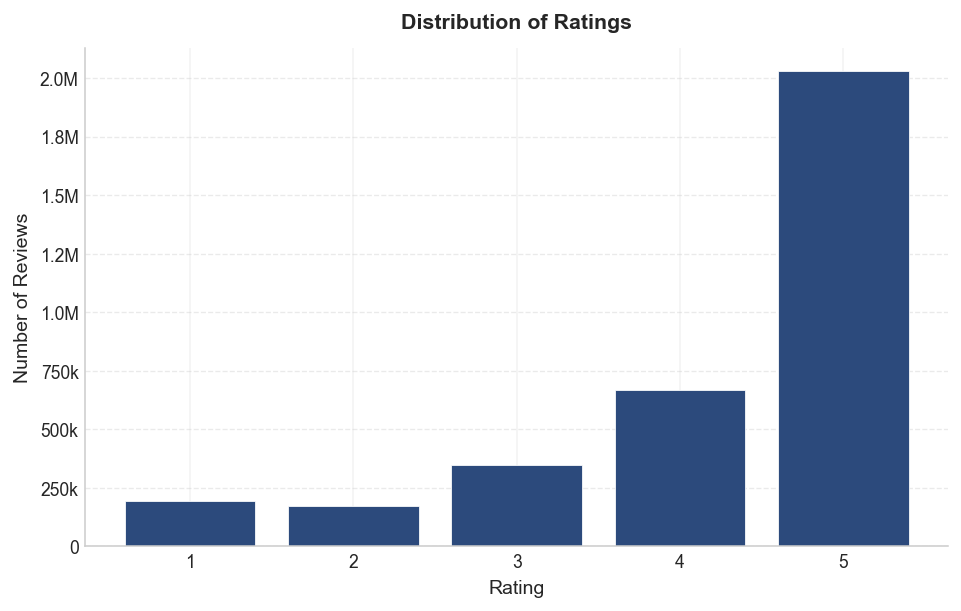

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(rating_counts.index.astype(int), rating_counts.values, color='#2c4a7c', edgecolor='white', linewidth=0.4)
ax.set_title("Distribution of Ratings", fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel("Rating", fontsize=10)
ax.set_ylabel("Number of Reviews", fontsize=10)
ax.set_xticks([1, 2, 3, 4, 5])
ax.tick_params(labelsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.grid(axis='y', linestyle='--', alpha=0.4, linewidth=0.7)
ax.set_ylim(bottom=0)

# Show e.g. "2.0M" instead of "2.00 1e6"
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
finalize_plot("01_rating_distribution.png")

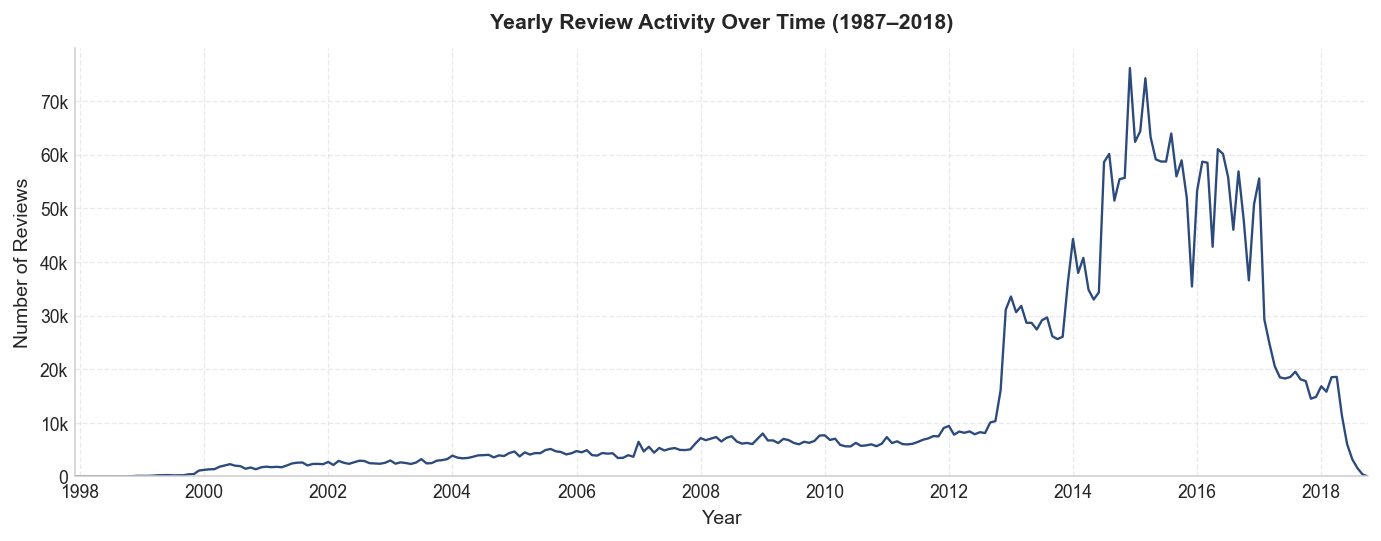

In [11]:
monthly_counts_clean = monthly_counts.dropna()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    monthly_counts_clean.index.astype(str),
    monthly_counts_clean.values,
    color='#2c4a7c',
    linewidth=1.2,
)

# Yearly ticks — show every 2 years to reduce crowding
labels = monthly_counts_clean.index.astype(str)
yearly_ticks = [i for i, label in enumerate(labels) if label.endswith('-01')]
shown_ticks = yearly_ticks[::2]  # every other year
ax.set_xticks(shown_ticks)
ax.set_xticklabels([labels[i][:4] for i in shown_ticks], rotation=0, ha='center', fontsize=9)
ax.yaxis.set_tick_params(labelsize=9)

# Labels & title
ax.set_title("Yearly Review Activity Over Time (1987–2018)", fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Number of Reviews", fontsize=10)

# Academic styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.grid(axis='both', linestyle='--', alpha=0.4, linewidth=0.7)  # x+y grid
ax.set_xlim(0, len(labels) - 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
ax.set_ylim(bottom=0)
finalize_plot("02_monthly_review_activity.png")

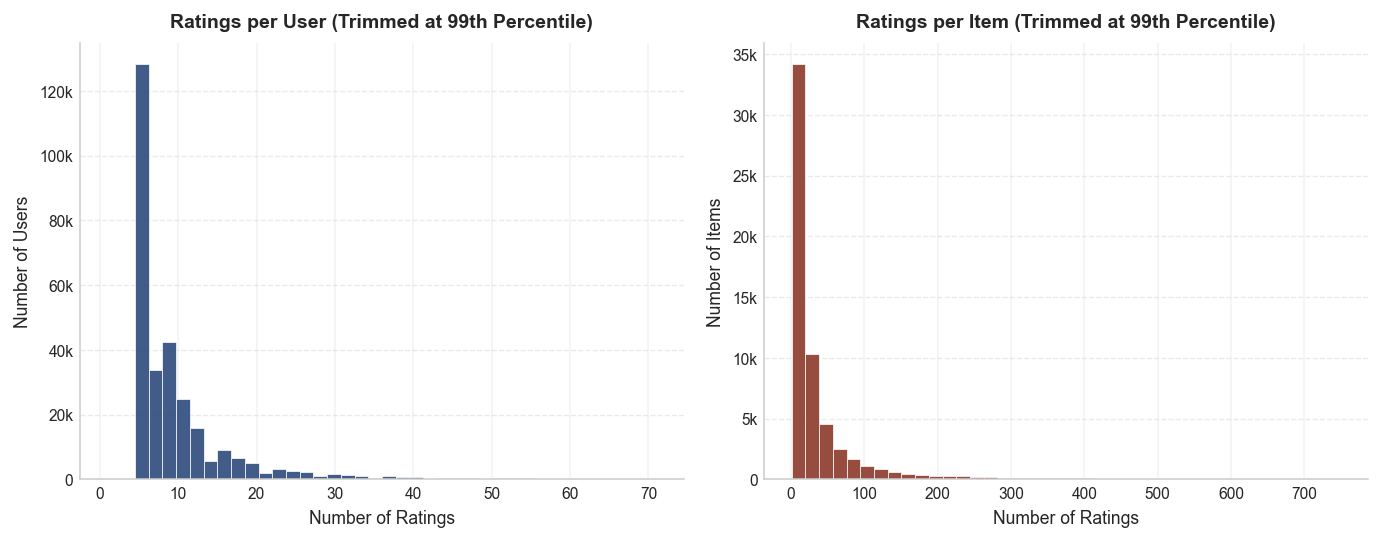

In [12]:
# Trim first
user_upper = ratings_per_user.quantile(USER_COUNT_UPPER_PERCENTILE / 100)
item_upper = ratings_per_item.quantile(ITEM_COUNT_UPPER_PERCENTILE / 100)
ratings_per_user_trimmed = ratings_per_user[ratings_per_user <= user_upper]
ratings_per_item_trimmed = ratings_per_item[ratings_per_item <= item_upper]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, data, color, title, xlabel, ylabel in [
    (axes[0], ratings_per_user_trimmed, '#2c4a7c',
     f'Ratings per User (Trimmed at {USER_COUNT_UPPER_PERCENTILE}th Percentile)',
     'Number of Ratings', 'Number of Users'),
    (axes[1], ratings_per_item_trimmed, '#8b3a2a',
     f'Ratings per Item (Trimmed at {ITEM_COUNT_UPPER_PERCENTILE}th Percentile)',
     'Number of Ratings', 'Number of Items'),
]:
    ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.4, alpha=0.9)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.grid(axis='y', linestyle='--', alpha=0.4, linewidth=0.7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
finalize_plot("03_long_tail_distributions.png")

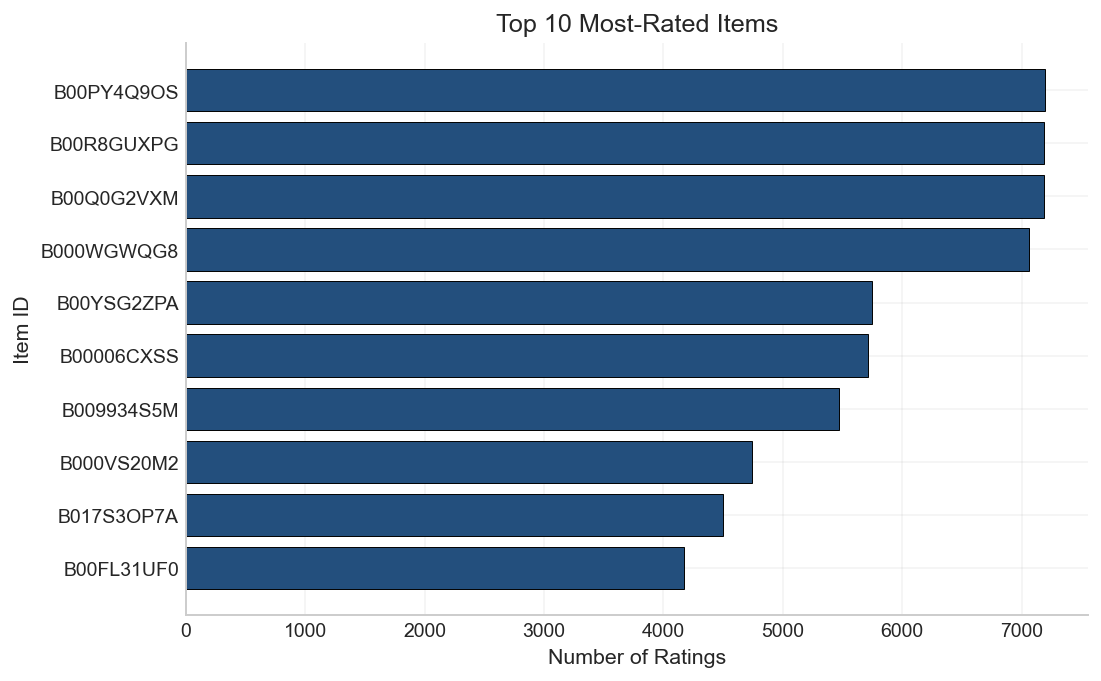

In [13]:
# Visual 4: top 10 most-rated items
plt.figure(figsize=(8, 5))
plt.barh(top_10_items.index.astype(str), top_10_items.values, color=main_color, edgecolor="black", linewidth=0.5)
plt.title("Top 10 Most-Rated Items")
plt.xlabel("Number of Ratings")
plt.ylabel("Item ID")
plt.gca().invert_yaxis()
finalize_plot("04_top_10_most_rated_items.png")


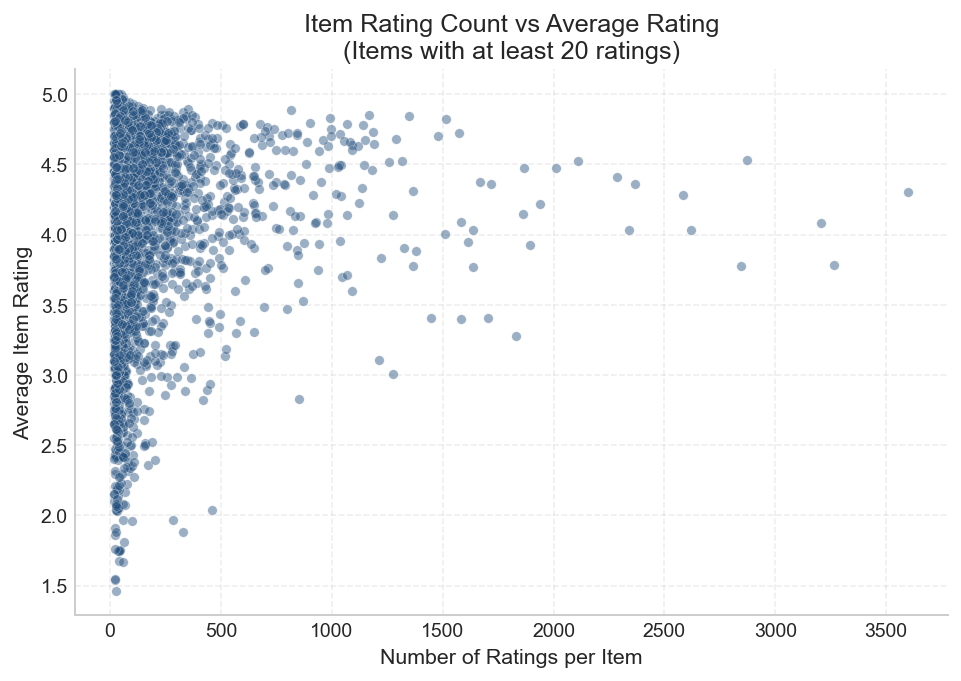

In [14]:
# Visual 5: item popularity vs average item rating
scatter_df = item_rating_summary[item_rating_summary["rating_count"] >= SCATTER_MIN_ITEM_RATINGS].copy()
if len(scatter_df) > SCATTER_SAMPLE_SIZE:
    scatter_df = scatter_df.sample(SCATTER_SAMPLE_SIZE, random_state=42)
plt.figure(figsize=(7, 5))
plt.scatter(scatter_df["rating_count"], scatter_df["average_rating"], s=24, alpha=0.45, color=main_color, edgecolors="white", linewidth=0.3)
plt.title(f"Item Rating Count vs Average Rating\n(Items with at least {SCATTER_MIN_ITEM_RATINGS} ratings)")
plt.xlabel("Number of Ratings per Item")
plt.ylabel("Average Item Rating")
plt.grid(True, linestyle="--", alpha=0.35)
finalize_plot("05_item_popularity_vs_average_rating.png")


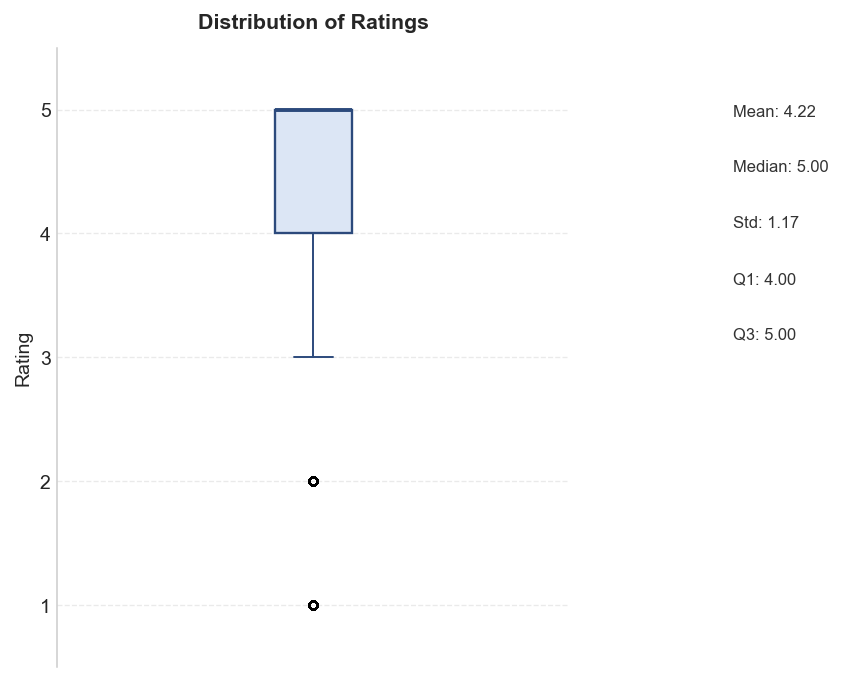

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))

data = rating_df["rating"].dropna()

# Boxplot
bp = ax.boxplot(data, vert=True, patch_artist=True,
    boxprops=dict(facecolor='#dce6f5', color='#2c4a7c', linewidth=1.2),
    medianprops=dict(color='#2c4a7c', linewidth=2),
    whiskerprops=dict(color='#2c4a7c', linewidth=1),
    capprops=dict(color='#2c4a7c', linewidth=1),
    flierprops=dict(marker='o', color='#2c4a7c', alpha=0.4, markersize=4))

# Annotate key stats on the right side
stats = {
    'Mean': data.mean(),
    'Median': data.median(),
    'Std': data.std(),
    'Q1': data.quantile(0.25),
    'Q3': data.quantile(0.75),
}
for i, (label, val) in enumerate(stats.items()):
    ax.annotate(f'{label}: {val:.2f}', xy=(1.32, 4.95 - i * 0.45),
                xycoords=('axes fraction', 'data'),
                fontsize=8.5, color='#333333')

ax.set_title("Distribution of Ratings", fontsize=11, fontweight='bold', pad=10)
ax.set_ylabel("Rating", fontsize=10)
ax.set_xticks([])
ax.set_ylim(0.5, 5.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4, linewidth=0.7)

plt.tight_layout()
finalize_plot("04_boxplot_ratings.png")